<a href="https://colab.research.google.com/github/eg424/MIP/blob/Simulation/Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install magpylib

# Magnets setup

In [53]:
import magpylib as mp
import numpy as np

# Positions for arrangement:

# Chain
p1 = (0,0,0)
p2 = (0.0026,0,0)
p3 = (0.0066,0,0)
p4 = (0.0106,0,0)

# Square
# p1 = (0,0,0)
# p2 = (0.0026,0,0)
# p3 = (0,0.0026,0)
# p4 = (0.0026,0.0026,0)

# Neodymium - N40 Magnets
m1 = mp.magnet.Sphere(
    polarization=(0,0,1.24), # Z-axis. Retrieved from (Hci): https://www.eclipsemagnetics.com/site/assets/files/19485/ndfeb_neodymium_iron_boron-standard_ndfeb_range_datasheet_rev1.pdf
    diameter=0.002, # 2mm
    position=p1
)

m2 = mp.magnet.Sphere(
    polarization=(0,0,1.24),
    diameter=0.002,
    position=p2
)

m3 = mp.magnet.Sphere(
    polarization=(0,0,1.24),
    diameter=0.002,
    position=p3
)

m4 = mp.magnet.Sphere(
    polarization=(0,0,1.24),
    diameter=0.002,
    position=p4
)

# Create a Sensor for measuring the field
sensor = mp.Sensor()

# Create a Collection to manage all magnets
magnets_collection = mp.Collection(m1, m2, m3, m4)

mp.show(magnets_collection, sensor, backend = 'plotly')

# Simulations

In [ ]:
# Compute the B-field at single observation point:
# Centre of chain
observer_point = (0.0056, 0, 0)
B_field = magnets_collection.getB(observer_point)
print(B_field) # 0.80569774 T

# Centre of square
# observer_point = (0.0026, 0.0023, 0)
# B_field = magnets_collection.getB(observer_point)
# print(B_field) # 0.75975859 T

[0.         0.         0.80569774]


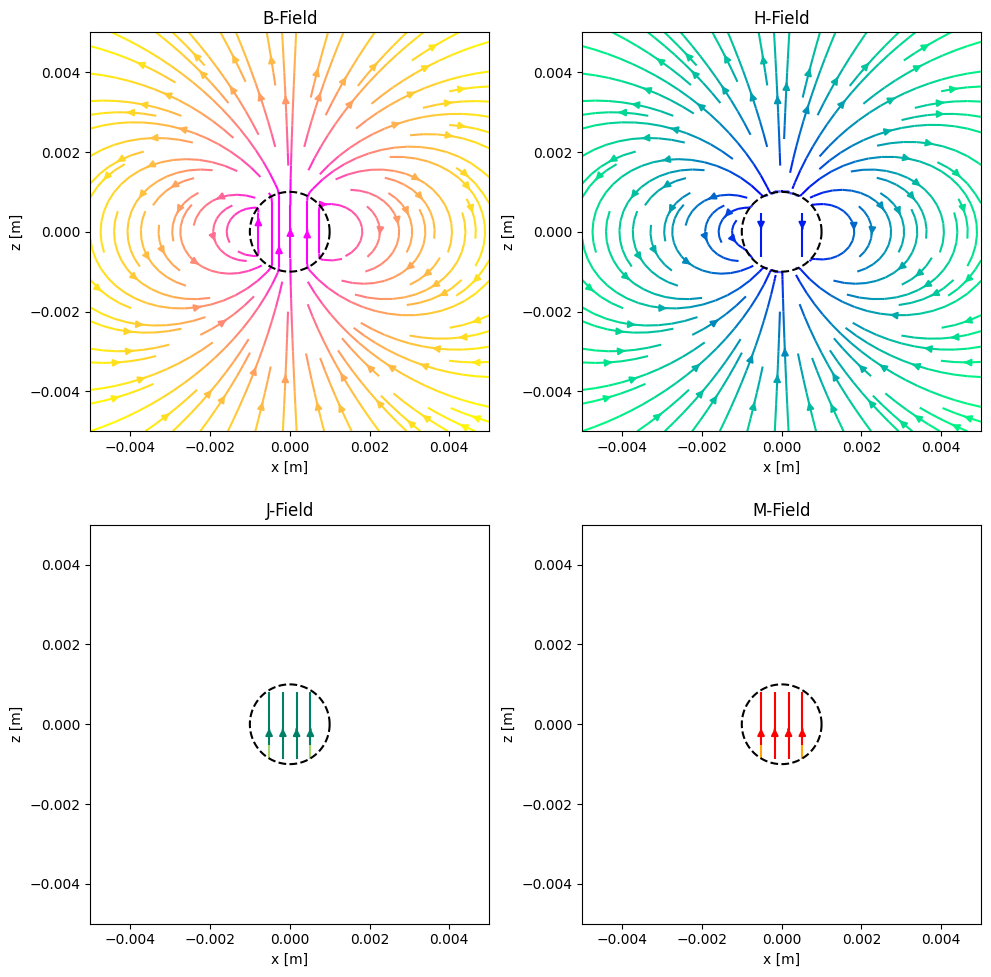

In [56]:
import matplotlib.pyplot as plt
from numpy.linalg import norm

fig, [[ax1,ax2], [ax3,ax4]] = plt.subplots(2, 2, figsize=(10, 10))

# Create a 2D grid in the X-Z plane at Y=0
# Use meshgrid for easier plotting with streamplot later
x_vals = np.linspace(-0.005, 0.005, 200)
z_vals = np.linspace(-0.005, 0.005, 200)
X, Z = np.meshgrid(x_vals, z_vals)

# Create the observation points array in the format expected by getB/getH/getJ/getM
grid_points = np.zeros((X.size, 3))
grid_points[:, 0] = X.ravel() # Reshape X to a 1D array and put in column 0
grid_points[:, 2] = Z.ravel() # Reshape Z to a 1D array and put in column 2

# Compute BHJM-fields of one spherical magnet on the grid
B = m1.getB(grid_points)
H = m1.getH(grid_points)
J = m1.getJ(grid_points)
M = m1.getM(grid_points)

# Reshape back to the grid shape for streamplot
Bx = B[:, 0].reshape(X.shape)
Bz = B[:, 2].reshape(X.shape)

Hx = H[:, 0].reshape(X.shape)
Hz = H[:, 2].reshape(X.shape)

Jx = J[:, 0].reshape(X.shape)
Jz = J[:, 2].reshape(X.shape)

Mx = M[:, 0].reshape(X.shape)
Mz = M[:, 2].reshape(X.shape)

# Calculate magnitude for coloring for B and H (use log scale as they can vary widely)
Bmag = np.clip(norm(B[:, [0,2]], axis=1).reshape(X.shape), 1e-12, None)
Hmag = np.clip(norm(H[:, [0,2]], axis=1).reshape(X.shape), 1e-12, None)

# Calculate magnitude for coloring for J and M (linear scale is usually fine)
Jmag = norm(J[:, [0,2]], axis=1).reshape(X.shape)
Mmag = norm(M[:, [0,2]], axis=1).reshape(X.shape)

# Display field with Pyplot
ax1.streamplot(X, Z, Bx, Bz, color=np.log(Bmag), cmap="spring_r")
ax2.streamplot(X, Z, Hx, Hz, color=np.log(Hmag), cmap="winter_r")
ax3.streamplot(X, Z, Jx, Jz, color=Jmag, cmap="summer_r")
ax4.streamplot(X, Z, Mx, Mz, color=Mmag, cmap="autumn_r")

ax1.set_title("B-Field")
ax2.set_title("H-Field")
ax3.set_title("J-Field")
ax4.set_title("M-Field")

for ax in [ax1,ax2,ax3,ax4]:
    ax.set(
        xlabel="x [m]", # Updated label to include units
        ylabel="z [m]", # Corrected ylabel to z-position as we are in XZ plane
        aspect=1,
        xlim=(-0.005, 0.005), # Set limits based on grid range
        ylim=(-0.005, 0.005), # Set limits based on grid range
    )
    # Outline magnet boundary
    # The magnet is centered at (0,0,0) and has diameter 0.002 m (radius 0.001 m)
    ts = np.linspace(0, 2 * np.pi, 100)
    ax.plot(0.001 * np.cos(ts), 0.001 * np.sin(ts), "k--")

plt.tight_layout()
plt.show()